In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Настройка стилей
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

# Загрузка данных
df = pd.read_csv('final_dataset_with_clusters.csv')

print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(f"Размер данных: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nСтатистика по числовым колонкам:")
print(df.describe())

# Проверка распределения по кластерам
print("\n=== РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ ===")
print("\nK-Means кластеры:")
print(df['cluster_kmeans'].value_counts().sort_index())
print("\nИерархические кластеры:")
print(df['cluster_hierarchical'].value_counts().sort_index())

=== ИНФОРМАЦИЯ О ДАННЫХ ===
Размер данных: (500, 10)

Колонки: ['measurement_id', 'timestamp', 'operation_name', 'duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load', 'cluster_hierarchical', 'cluster_kmeans']

Типы данных:
measurement_id            int64
timestamp                   str
operation_name              str
duration_ms             float64
data_size                 int64
n_queries                 int64
is_peak_hour              int64
server_load             float64
cluster_hierarchical      int64
cluster_kmeans            int64
dtype: object

Статистика по числовым колонкам:
       measurement_id  duration_ms   data_size   n_queries  is_peak_hour  \
count      500.000000   500.000000  500.000000  500.000000    500.000000   
mean       250.500000   404.128700  229.800000  118.222000      0.502000   
std        144.481833   382.345923  160.166371  159.491127      0.500497   
min          1.000000     1.000000   50.000000    1.000000      0.000000   
25%        

In [3]:
# Выбираем только числовые признаки для корреляционного анализа
# Исключаем measurement_id (ID), timestamp (время), operation_name (категория), и метки кластеров
numeric_features = ['duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load']

# Создаём датасет для анализа
df_numeric = df[numeric_features]

print("Датасет для корреляционного анализа:")
print(df_numeric.head())
print(f"\nРазмер: {df_numeric.shape}")

Датасет для корреляционного анализа:
   duration_ms  data_size  n_queries  is_peak_hour  server_load
0        42.26        200          2             1        0.170
1       488.75         50         51             0        0.259
2        23.82        300          1             1        0.659
3       791.66        100        101             1        0.778
4        52.88        300          2             1        0.603

Размер: (500, 5)


In [4]:
# Корреляция Пирсона (линейная связь)
pearson_corr = df_numeric.corr(method='pearson')

# Корреляция Спирмена (ранговая, для монотонных связей)
spearman_corr = df_numeric.corr(method='spearman')

print("=== КОРРЕЛЯЦИЯ ПИРСОНА ===")
print(pearson_corr.round(3))
print("\n=== КОРРЕЛЯЦИЯ СПИРМЕНА ===")
print(spearman_corr.round(3))

=== КОРРЕЛЯЦИЯ ПИРСОНА ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.194      0.862         0.139       -0.048
data_size           0.194      1.000      0.484         0.094        0.055
n_queries           0.862      0.484      1.000         0.021       -0.010
is_peak_hour        0.139      0.094      0.021         1.000       -0.053
server_load        -0.048      0.055     -0.010        -0.053        1.000

=== КОРРЕЛЯЦИЯ СПИРМЕНА ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.278      0.923         0.188       -0.049
data_size           0.278      1.000      0.263         0.097        0.050
n_queries           0.923      0.263      1.000        -0.007       -0.046
is_peak_hour        0.188      0.097     -0.007         1.000       -0.051
server_load        -0.049      0.050     -0.046        -0.051        1.000


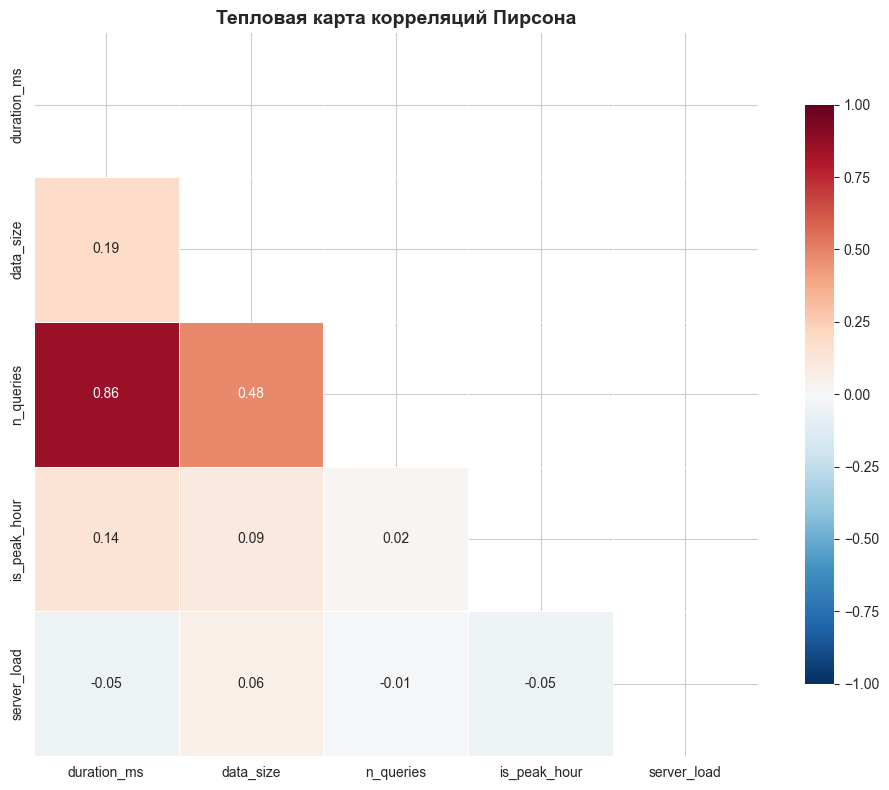

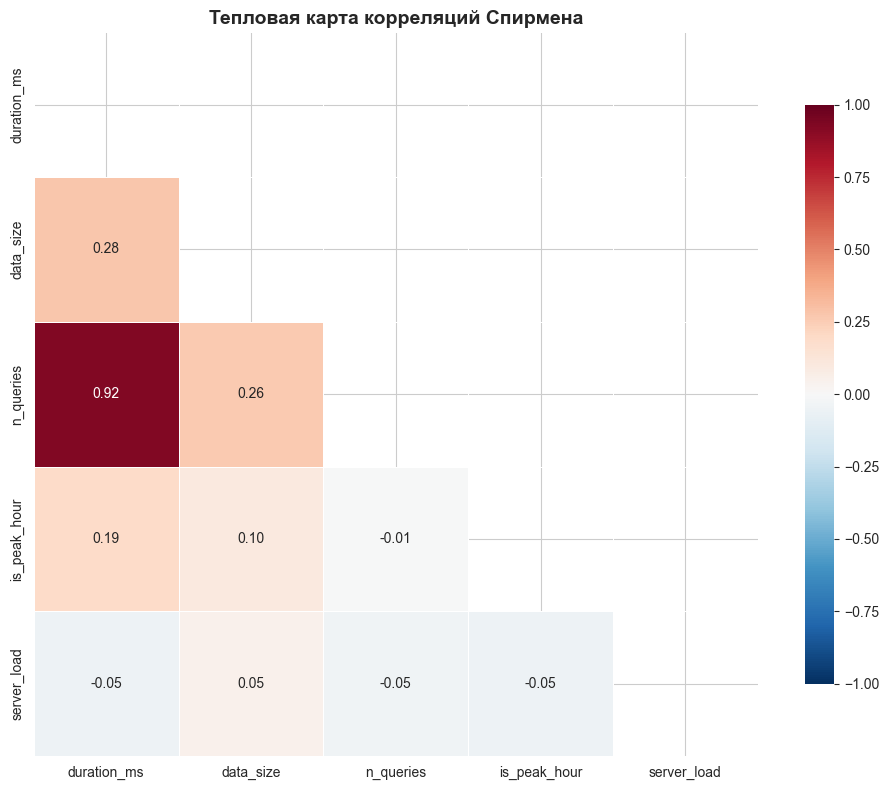

In [5]:
# Создаём маску для верхней треугольной части
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# Рисуем тепловую карту Пирсона
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, 
            mask=mask,
            annot=True,  # показываем числа
            cmap='RdBu_r',  # красный = отриц, синий = полож
            center=0,
            vmin=-1, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций Пирсона', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_pearson.png', dpi=150)
plt.show()

# То же для Спирмена
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций Спирмена', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_spearman.png', dpi=150)
plt.show()

In [6]:
# Функция для расчёта p-value для всех пар признаков
def calculate_correlation_pvalues(df):
    """Рассчитывает p-value для корреляций Пирсона"""
    cols = df.columns
    n_cols = len(cols)
    pvalues = pd.DataFrame(np.zeros((n_cols, n_cols)), columns=cols, index=cols)
    
    for i in range(n_cols):
        for j in range(n_cols):
            if i == j:
                pvalues.iloc[i, j] = 0
            else:
                # Убираем NaN, если есть
                clean_df = df[[cols[i], cols[j]]].dropna()
                corr, p_value = stats.pearsonr(clean_df[cols[i]], clean_df[cols[j]])
                pvalues.iloc[i, j] = p_value
    return pvalues

# Рассчитываем p-values
p_values = calculate_correlation_pvalues(df_numeric)

print("=== P-VALUES (значимость корреляций) ===")
print(p_values.round(5))

# Выделяем значимые корреляции (p < 0.05)
print("\n=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===")
significant_corr = pearson_corr.copy()
significant_mask = p_values > 0.05
significant_corr[significant_mask] = np.nan
print(significant_corr.round(3))

=== P-VALUES (значимость корреляций) ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms       0.00000    0.00001    0.00000       0.00178      0.28673
data_size         0.00001    0.00000    0.00000       0.03512      0.21829
n_queries         0.00000    0.00000    0.00000       0.64235      0.83211
is_peak_hour      0.00178    0.03512    0.64235       0.00000      0.23307
server_load       0.28673    0.21829    0.83211       0.23307      0.00000

=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.194      0.862         0.139          NaN
data_size           0.194      1.000      0.484         0.094          NaN
n_queries           0.862      0.484      1.000           NaN          NaN
is_peak_hour        0.139      0.094        NaN         1.000          NaN
server_load           NaN        NaN        NaN           NaN          1.0


In [7]:
# Функция для расчёта p-value для всех пар признаков
def calculate_correlation_pvalues(df):
    """Рассчитывает p-value для корреляций Пирсона"""
    cols = df.columns
    n_cols = len(cols)
    pvalues = pd.DataFrame(np.zeros((n_cols, n_cols)), columns=cols, index=cols)
    
    for i in range(n_cols):
        for j in range(n_cols):
            if i == j:
                pvalues.iloc[i, j] = 0
            else:
                # Убираем NaN, если есть
                clean_df = df[[cols[i], cols[j]]].dropna()
                corr, p_value = stats.pearsonr(clean_df[cols[i]], clean_df[cols[j]])
                pvalues.iloc[i, j] = p_value
    return pvalues

# Рассчитываем p-values
p_values = calculate_correlation_pvalues(df_numeric)

print("=== P-VALUES (значимость корреляций) ===")
print(p_values.round(5))

# Выделяем значимые корреляции (p < 0.05)
print("\n=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===")
significant_corr = pearson_corr.copy()
significant_mask = p_values > 0.05
significant_corr[significant_mask] = np.nan
print(significant_corr.round(3))

=== P-VALUES (значимость корреляций) ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms       0.00000    0.00001    0.00000       0.00178      0.28673
data_size         0.00001    0.00000    0.00000       0.03512      0.21829
n_queries         0.00000    0.00000    0.00000       0.64235      0.83211
is_peak_hour      0.00178    0.03512    0.64235       0.00000      0.23307
server_load       0.28673    0.21829    0.83211       0.23307      0.00000

=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.194      0.862         0.139          NaN
data_size           0.194      1.000      0.484         0.094          NaN
n_queries           0.862      0.484      1.000           NaN          NaN
is_peak_hour        0.139      0.094        NaN         1.000          NaN
server_load           NaN        NaN        NaN           NaN          1.0


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Добавляем константу для VIF
X = df_numeric.copy()

# Рассчитываем VIF для каждого признака
vif_data = pd.DataFrame()
vif_data["Признак"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("=== VIF (Variance Inflation Factor) ===")
print(vif_data.round(2))
print("\n=== ИНТЕРПРЕТАЦИЯ ===")
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        print(f"⚠️ {row['Признак']}: VIF = {row['VIF']:.2f} -> СИЛЬНАЯ мультиколлинеарность, требуется удаление")
    elif row['VIF'] > 5:
        print(f"⚡ {row['Признак']}: VIF = {row['VIF']:.2f} -> Умеренная мультиколлинеарность")
    else:
        print(f"✓ {row['Признак']}: VIF = {row['VIF']:.2f} -> Нет проблем")

=== VIF (Variance Inflation Factor) ===
        Признак   VIF
0   duration_ms  9.85
1     data_size  4.37
2     n_queries  9.55
3  is_peak_hour  2.25
4   server_load  3.29

=== ИНТЕРПРЕТАЦИЯ ===
⚡ duration_ms: VIF = 9.85 -> Умеренная мультиколлинеарность
✓ data_size: VIF = 4.37 -> Нет проблем
⚡ n_queries: VIF = 9.55 -> Умеренная мультиколлинеарность
✓ is_peak_hour: VIF = 2.25 -> Нет проблем
✓ server_load: VIF = 3.29 -> Нет проблем


=== АНАЛИЗ ПО КЛАСТЕРАМ K-MEANS ===


--- КЛАСТЕР 0 (K-Means) ---
Количество объектов: 206

Корреляционная матрица:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.373      0.858         0.207       -0.070
data_size           0.373      1.000      0.239         0.092        0.035
n_queries           0.858      0.239      1.000         0.076       -0.077
is_peak_hour        0.207      0.092      0.076         1.000       -0.065
server_load        -0.070      0.035     -0.077        -0.065        1.000


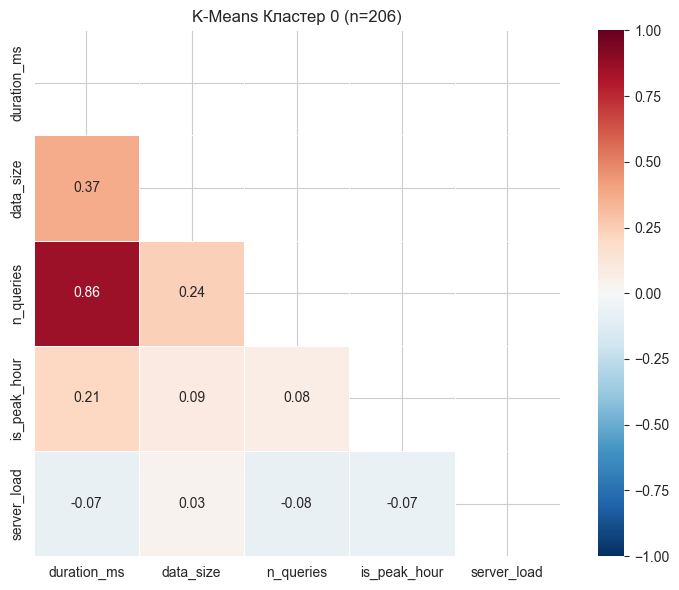


--- КЛАСТЕР 1 (K-Means) ---
Количество объектов: 104

Корреляционная матрица:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.604      0.604         0.782        0.001
data_size           0.604      1.000      1.000         0.062        0.190
n_queries           0.604      1.000      1.000         0.062        0.190
is_peak_hour        0.782      0.062      0.062         1.000       -0.146
server_load         0.001      0.190      0.190        -0.146        1.000


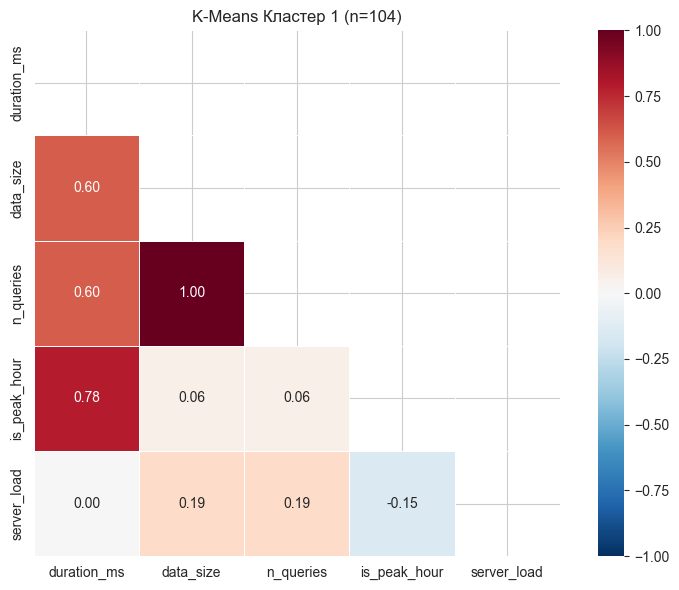


--- КЛАСТЕР 2 (K-Means) ---
Количество объектов: 190

Корреляционная матрица:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000     -0.311      0.743         0.241       -0.105
data_size          -0.311      1.000      0.123         0.100        0.104
n_queries           0.743      0.123      1.000        -0.017       -0.086
is_peak_hour        0.241      0.100     -0.017         1.000        0.010
server_load        -0.105      0.104     -0.086         0.010        1.000


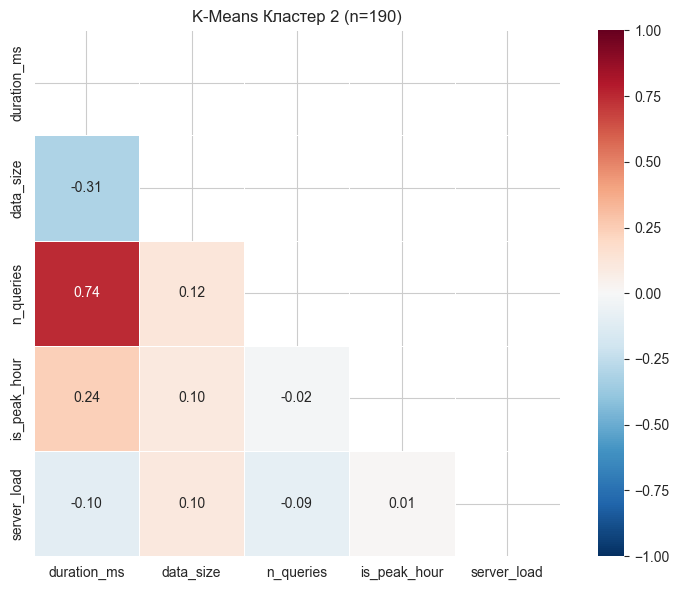

In [9]:
# Анализ по кластерам K-Means
print("=== АНАЛИЗ ПО КЛАСТЕРАМ K-MEANS ===\n")

# Создаём словарь для хранения корреляций по кластерам
cluster_correlations = {}

for cluster in sorted(df['cluster_kmeans'].unique()):
    print(f"\n--- КЛАСТЕР {cluster} (K-Means) ---")
    print(f"Количество объектов: {len(df[df['cluster_kmeans'] == cluster])}")
    
    # Выбираем данные кластера
    cluster_data = df[df['cluster_kmeans'] == cluster][numeric_features]
    
    # Рассчитываем корреляцию Пирсона
    corr_matrix = cluster_data.corr(method='pearson')
    cluster_correlations[cluster] = corr_matrix
    
    print("\nКорреляционная матрица:")
    print(corr_matrix.round(3))
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdBu_r',
                center=0,
                vmin=-1, vmax=1,
                square=True,
                fmt='.2f',
                linewidths=0.5)
    plt.title(f'K-Means Кластер {cluster} (n={len(cluster_data)})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'heatmap_kmeans_cluster_{cluster}.png', dpi=150)
    plt.show()